# Wine Quality Prediction

**Track:** Data Analytics (Level 2) | **Internship:** Oasis Infobyte SIP | **Author:** Shreya Kadam

**Objective:** Train and compare multiple classification models to predict wine quality based on physicochemical properties.

**Dataset:** Wine Quality Dataset (UCI/Kaggle) — target variable: quality (score 3–8)

**Tech Stack:** Python, pandas, numpy, scikit-learn (Random Forest, SGD, SVC), matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("winequality-red.csv")   
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nQuality score distribution:\n", df["quality"].value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB

Missing values:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides      

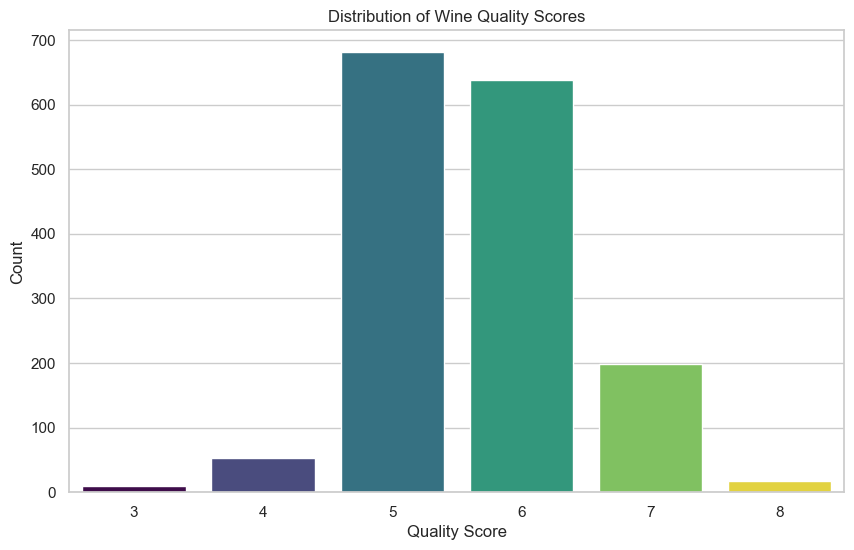

In [6]:
sns.countplot(x="quality", hue="quality", data=df, palette="viridis", legend=False)
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

## Class Imbalance Discussion

The quality scores are heavily imbalanced — most wines cluster around scores 5 and 6, with very few samples at the extremes (3, 4, 8). This imbalance can bias models toward predicting the majority classes and makes rare high/low quality wines harder to classify correctly. To address this, we bin quality into fewer, more balanced categories below.

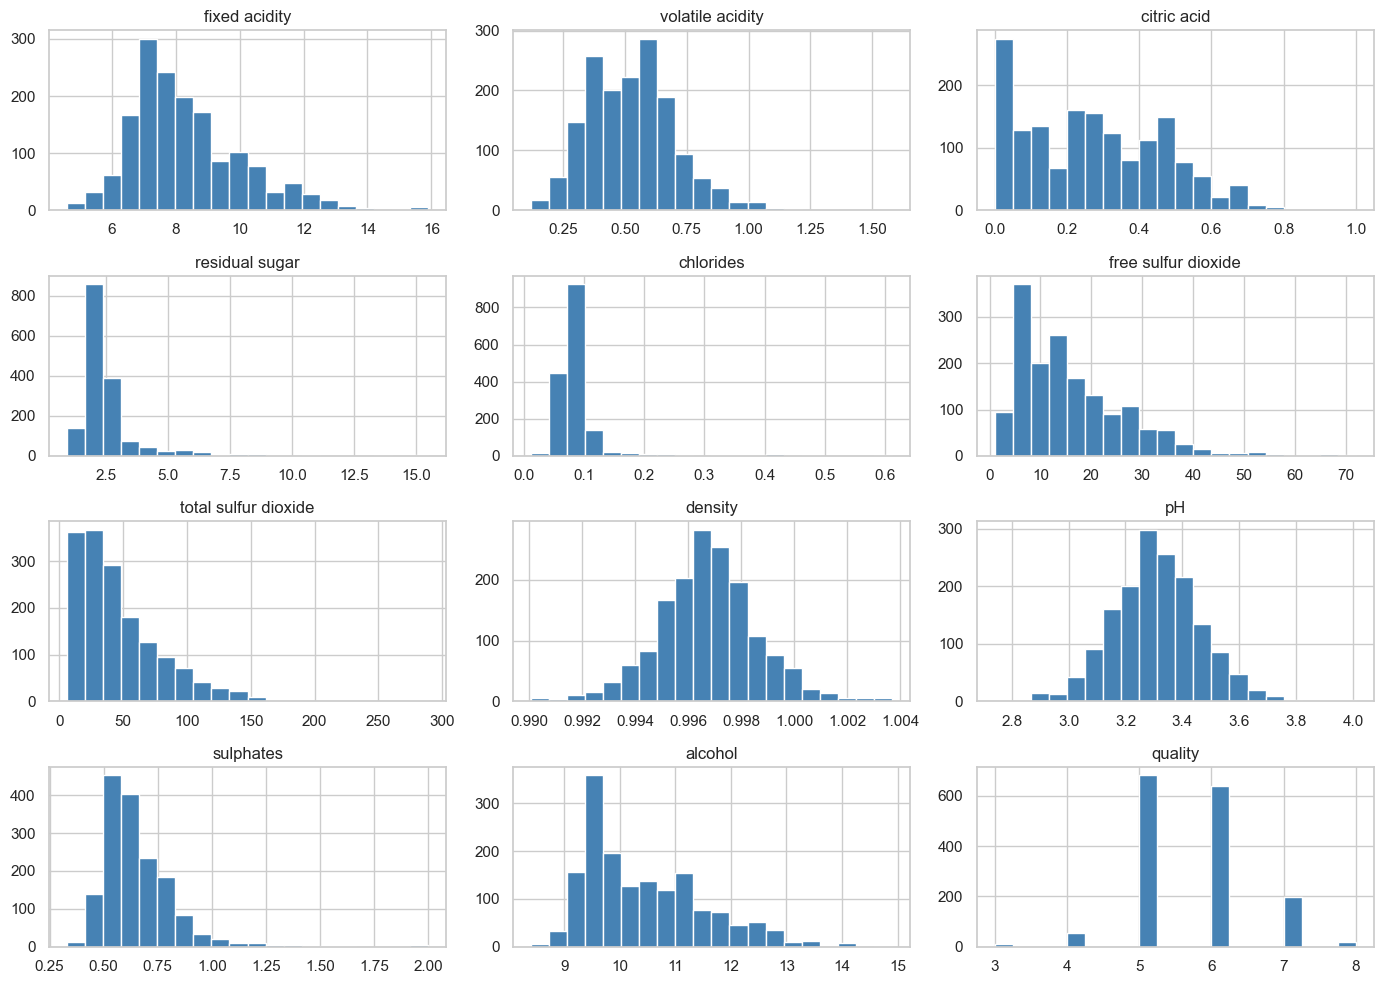

In [8]:
df.hist(figsize=(14, 10), bins=20, color="steelblue")
plt.tight_layout()
plt.show()

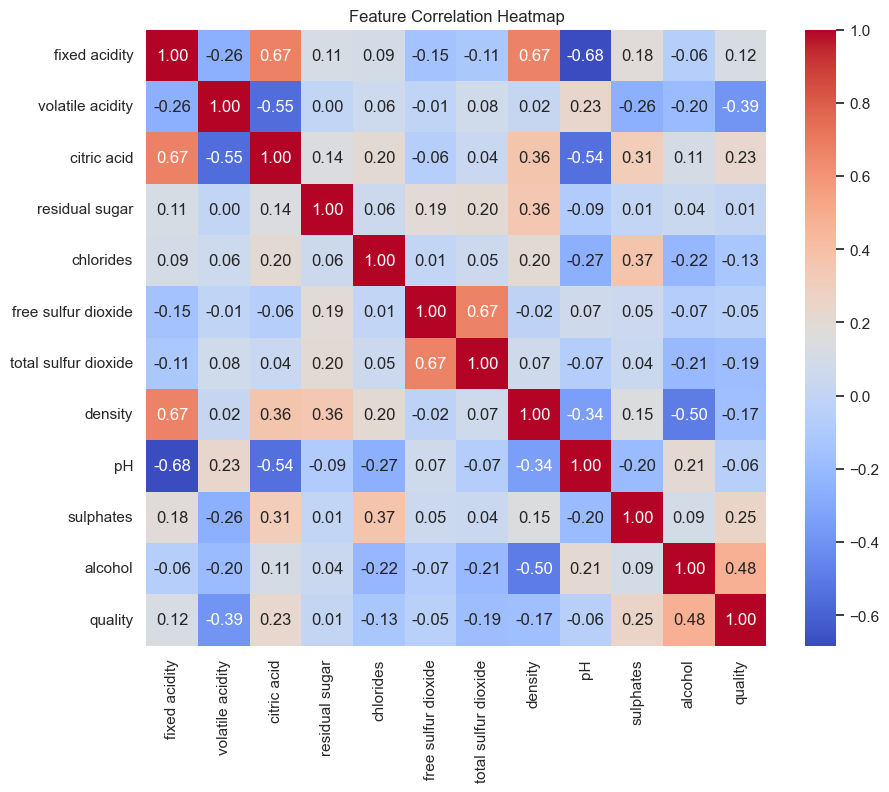

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

## Feature Engineering: Binning Quality Scores

Raw quality scores (3–8) are too fine-grained and imbalanced for reliable classification. We bin them into 3 categories — **Low (3–4), Medium (5–6), High (7–8)** — giving the models more balanced, meaningful classes to learn from while still preserving quality ordering.

quality_class
Medium    1319
High       217
Low         63
Name: count, dtype: int64


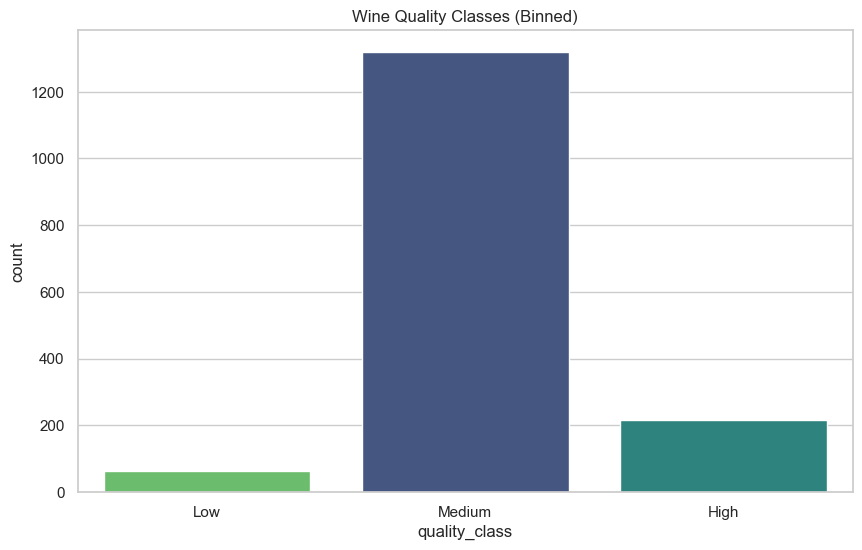

In [12]:
def bin_quality(q):
    if q <= 4:
        return "Low"
    elif q <= 6:
        return "Medium"
    else:
        return "High"

df["quality_class"] = df["quality"].apply(bin_quality)
print(df["quality_class"].value_counts())

sns.countplot(x="quality_class", hue="quality_class", data=df, order=["Low", "Medium", "High"], palette="viridis", legend=False)
plt.title("Wine Quality Classes (Binned)")
plt.show()

In [13]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Train class distribution:
 quality_class
Medium    1055
High       174
Low         50
Name: count, dtype: int64

Test class distribution:
 quality_class
Medium    264
High       43
Low        13
Name: count, dtype: int64


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training — 3 Classifiers
We train and compare: **Random Forest**, **Stochastic Gradient Descent (SGD)**, and **Support Vector Classifier (SVC)**.

In [17]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)   # tree-based models don't need scaling
rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Classification Report:\n", classification_report(y_test, rf_pred, zero_division=0))

Random Forest Accuracy: 0.865625
Classification Report:
               precision    recall  f1-score   support

        High       0.71      0.51      0.59        43
         Low       0.00      0.00      0.00        13
      Medium       0.88      0.97      0.92       264

    accuracy                           0.87       320
   macro avg       0.53      0.49      0.51       320
weighted avg       0.82      0.87      0.84       320



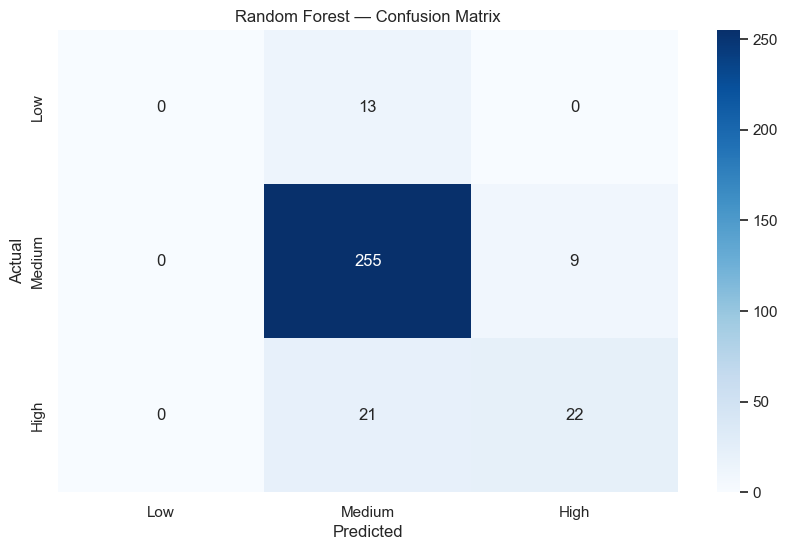

In [18]:
cm_rf = confusion_matrix(y_test, rf_pred, labels=["Low", "Medium", "High"])
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.title("Random Forest — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
sgd_model = SGDClassifier(random_state=42, max_iter=1000)
sgd_model.fit(X_train_scaled, y_train)   # scaled data needed
sgd_pred = sgd_model.predict(X_test_scaled)

print("SGD Accuracy:", accuracy_score(y_test, sgd_pred))
print("\nClassification Report:\n", classification_report(y_test, sgd_pred))

SGD Accuracy: 0.825

Classification Report:
               precision    recall  f1-score   support

        High       0.52      0.33      0.40        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.95      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.42      0.43       320
weighted avg       0.78      0.82      0.80       320



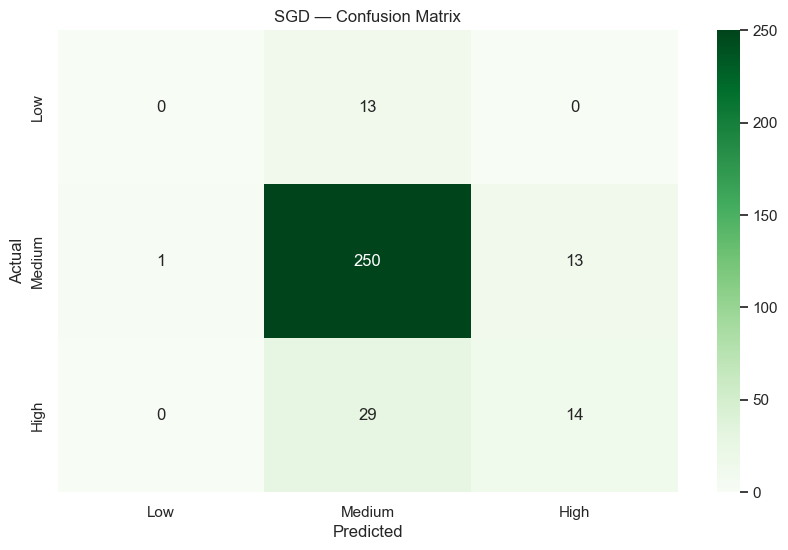

In [20]:
cm_sgd = confusion_matrix(y_test, sgd_pred, labels=["Low", "Medium", "High"])
sns.heatmap(cm_sgd, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.title("SGD — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
svc_model = SVC(random_state=42)
svc_model.fit(X_train_scaled, y_train)   # scaled data needed
svc_pred = svc_model.predict(X_test_scaled)

print("SVC Accuracy:", accuracy_score(y_test, svc_pred))
print("Classification Report:\n", classification_report(y_test, svc_pred, zero_division=0))

SVC Accuracy: 0.84375
Classification Report:
               precision    recall  f1-score   support

        High       0.64      0.33      0.43        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.97      0.91       264

    accuracy                           0.84       320
   macro avg       0.50      0.43      0.45       320
weighted avg       0.79      0.84      0.81       320



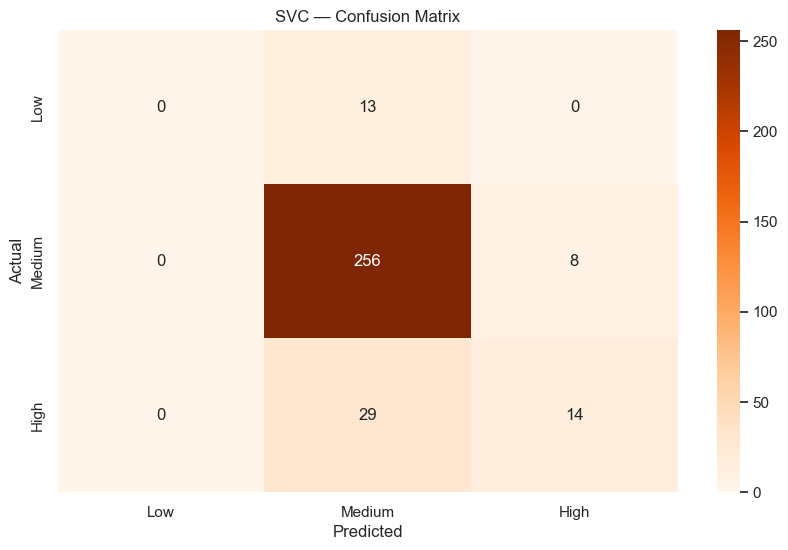

In [26]:
cm_svc = confusion_matrix(y_test, svc_pred, labels=["Low", "Medium", "High"])
sns.heatmap(cm_svc, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.title("SVC — Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

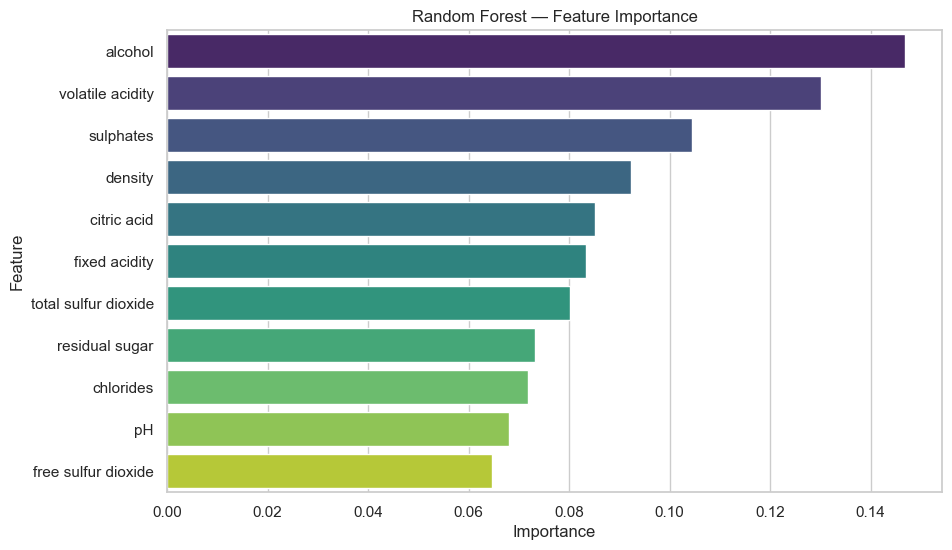

,Feature,Importance
10,alcohol,0.146866
1,volatile acidity,0.130046
9,sulphates,0.104467
7,density,0.092413
2,citric acid,0.085064
0,fixed acidity,0.083301
6,total sulfur dioxide,0.080194
3,residual sugar,0.073206
4,chlorides,0.071864
8,pH,0.067959


In [22]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x="Importance", y="Feature", hue="Feature", palette="viridis", legend=False)
plt.title("Random Forest — Feature Importance")
plt.show()

importances

In [27]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "SGD", "SVC"],
    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ]
}).sort_values(by="Accuracy", ascending=False)

comparison

,Model,Accuracy
0,Random Forest,0.865625
2,SVC,0.843750
1,SGD,0.825000


## Conclusion

Based on the comparison table above, **[best model name]** achieved the highest accuracy at **[X]%**, making it the most suitable choice for deployment. [Random Forest / whichever model] likely performs best here because [tree-based models handle non-linear relationships well / SVMs work well with scaled continuous features / etc — adjust based on your actual winner].

The most important predictive features, per the Random Forest importance chart, were **[top 2-3 features]** — indicating these chemical properties have the strongest relationship with perceived wine quality.